In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [23]:
df = pd.read_csv("telecom_churn.csv")
df.head()

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


In [24]:
df = df.sample(12000, random_state=42)
df.shape

(12000, 14)

In [25]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 12000 entries, 230796 to 222536
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   customer_id           12000 non-null  int64 
 1   telecom_partner       12000 non-null  object
 2   gender                12000 non-null  object
 3   age                   12000 non-null  int64 
 4   state                 12000 non-null  object
 5   city                  12000 non-null  object
 6   pincode               12000 non-null  int64 
 7   date_of_registration  12000 non-null  object
 8   num_dependents        12000 non-null  int64 
 9   estimated_salary      12000 non-null  int64 
 10  calls_made            12000 non-null  int64 
 11  sms_sent              12000 non-null  int64 
 12  data_used             12000 non-null  int64 
 13  churn                 12000 non-null  int64 
dtypes: int64(9), object(5)
memory usage: 1.4+ MB


,customer_id,age,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,122409.970667,45.766000,549133.975667,1.969667,85009.166083,48.663583,23.758750,4986.140917,0.198500
std,70201.211229,16.465196,259371.646461,1.414478,37177.904427,29.474375,14.675836,2943.238785,0.398887
min,13.000000,18.000000,100176.000000,0.000000,20001.000000,-10.000000,-5.000000,-962.000000,0.000000
25%,61546.750000,32.000000,325289.750000,1.000000,53225.000000,24.000000,11.000000,2490.000000,0.000000
50%,122672.000000,46.000000,548866.500000,2.000000,85291.000000,48.000000,24.000000,4967.000000,0.000000
75%,182808.750000,60.000000,772600.750000,3.000000,117152.500000,74.000000,36.000000,7470.250000,0.000000
max,243531.000000,74.000000,999974.000000,4.000000,149993.000000,108.000000,53.000000,10964.000000,1.000000


In [26]:
df = df[['age','gender','city','state','calls_made','sms_sent',
         'data_used','estimated_salary','churn']]

In [27]:
df.isnull().sum()

age                 0
gender              0
city                0
state               0
calls_made          0
sms_sent            0
data_used           0
estimated_salary    0
churn               0
dtype: int64

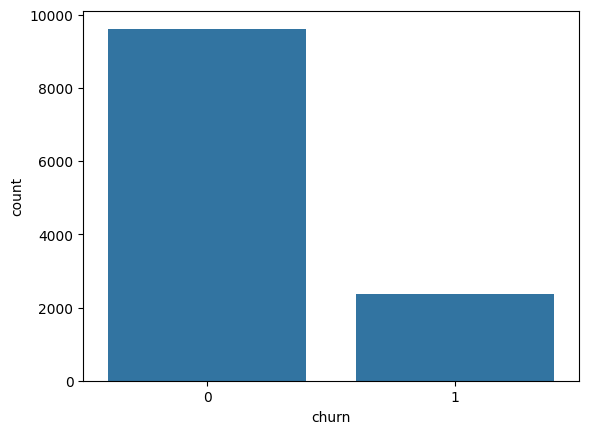

In [28]:
# Churn count
sns.countplot(x='churn', data=df)
plt.show()

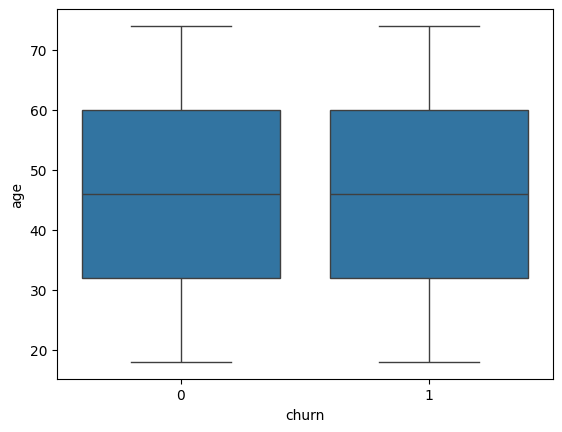

In [29]:
# Age vs Churn
sns.boxplot(x='churn', y='age', data=df)
plt.show()

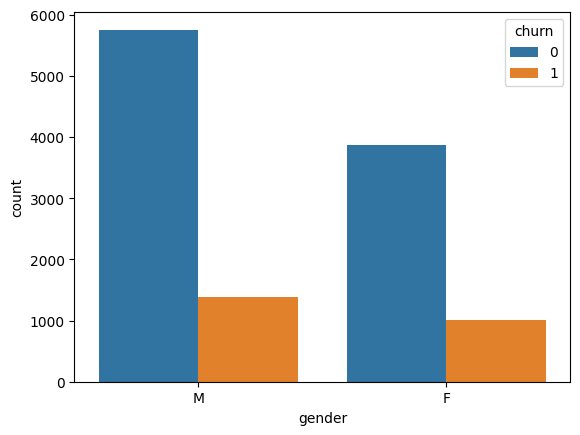

In [30]:
# Gender vs Churn
sns.countplot(x='gender', hue='churn', data=df)
plt.show()

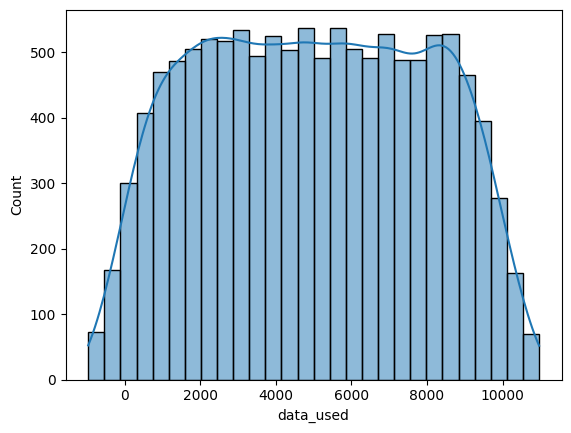

In [31]:
# Data Usage vs Churn
sns.histplot(df['data_used'], kde=True)
plt.show()

In [32]:
le = LabelEncoder()

for col in ['gender','city','state']:
    df[col] = le.fit_transform(df[col])

In [33]:
X = df.drop('churn', axis=1)
y = df['churn']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [36]:
y_pred = model.predict(X_test)

In [37]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.80125
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1924
           1       0.33      0.00      0.00       476

    accuracy                           0.80      2400
   macro avg       0.57      0.50      0.45      2400
weighted avg       0.71      0.80      0.71      2400



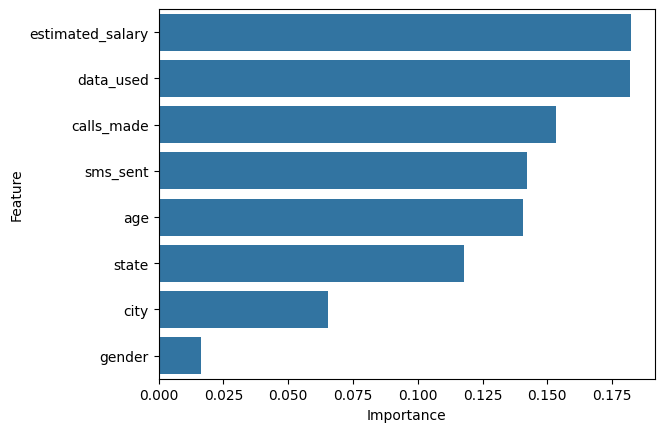

In [38]:
importances = model.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.show()

In [39]:
import pickle
pickle.dump(model, open("model.pkl", "wb"))

In [40]:
from sklearn.preprocessing import LabelEncoder
import pickle

df = pd.read_csv("telecom_churn.csv")

encoders = {}

for col in ['gender','city','state']:
    le = LabelEncoder()
    df[col] = df[col].astype(str)   # 🔥 important
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

pickle.dump(encoders, open("encoders.pkl","wb"))

In [41]:
print(encoders['gender'].classes_)

['F' 'M']
